In [ ]:
import torch
import numpy as np
from Network import VAE, VAE_41
from torch.utils.data import DataLoader
from Util.data_loader import loader_cre
from Util.metrics import SSIM
from Util.train_utils import train_vae, plot_curve
from Util.Visualize import Plot
import os
import torch.optim as optim


In [2]:
output_dir = r"D:\研三\代码\VAE\split_3d_data" #数据路径
batch_size = 32  # 设置批次大小

train_dataset, val_dataset, test_dataset = loader_cre(output_dir, dataset_type="scaled")
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Loading train data from D:\研三\代码\VAE\split_3d_data\train_data_scaled.npy
Loading validation data from D:\研三\代码\VAE\split_3d_data\val_data_scaled.npy
Loading test data from D:\研三\代码\VAE\split_3d_data\test_data_scaled.npy


In [3]:
model = VAE()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

LEARNING_RATE = 5e-4
NUM_EPOCHS = 10
BETA = 0.01 # KL 散度权重
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
save_path = "./weight/std_kl_01.pth"
if not os.path.exists("./weight"):
    os.makedirs(".weight")
# ----------------------------------------------------
# 模型的训练函数调用也需要更新，传入 val_loader
# 假设您的 train_vae 函数也返回验证损失历史记录
trained_model, losses, recon, kl, val_losses = train_vae(
    model, 
    train_loader,        # <-- 训练数据加载器
    val_loader,          # <-- 验证数据加载器 (新增)
    optimizer, 
    NUM_EPOCHS, 
    device, 
    BETA,
    save_path
)

====> Epoch: 0/10 Average loss: 0.0434
-> 模型权重已保存到: ./weight/std_kl_01.pth


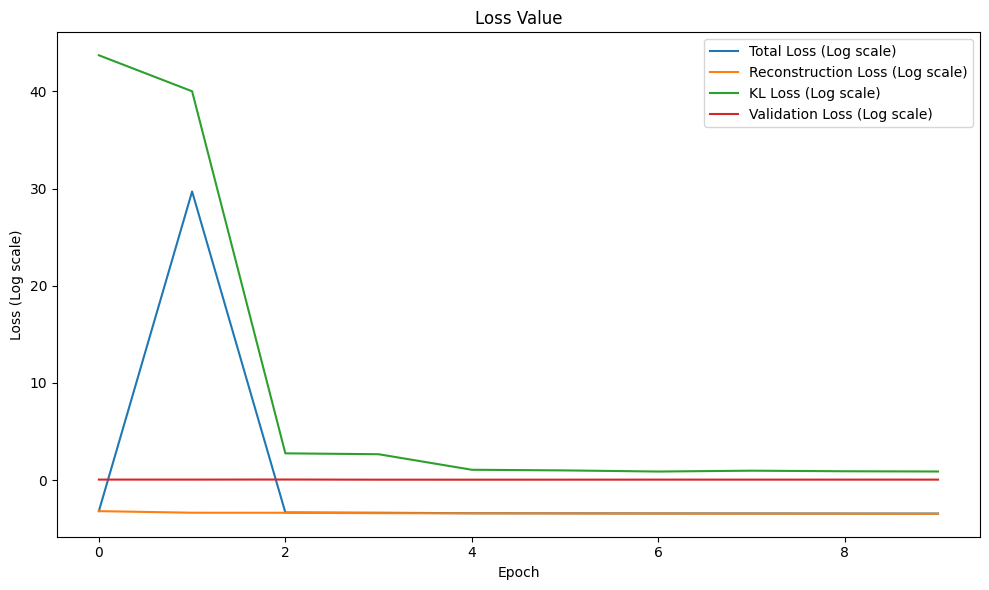

In [8]:
plot_curve(losses, recon, kl, val_losses, log_scale=True)

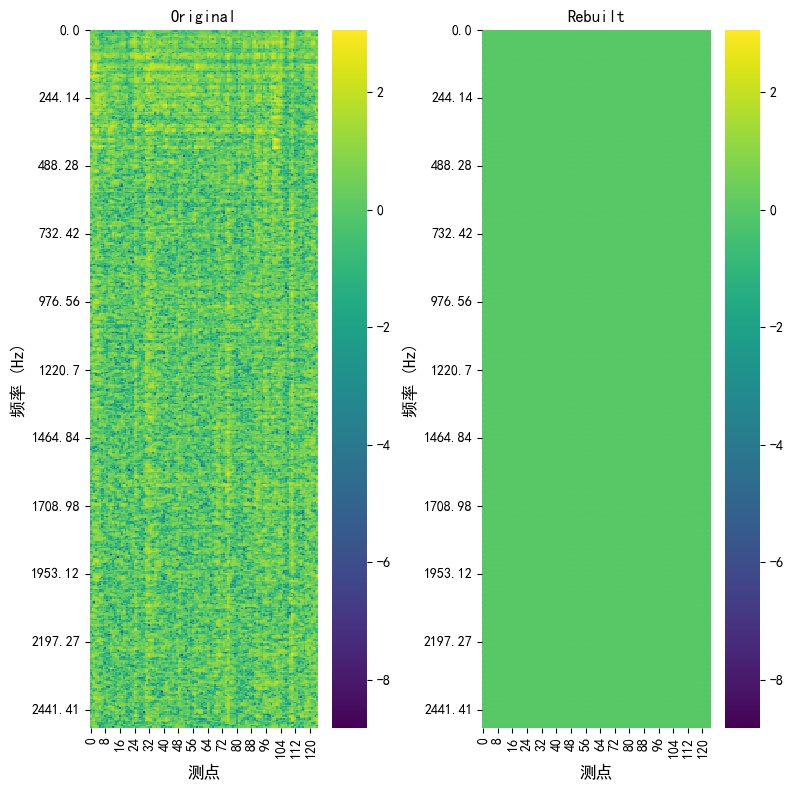

In [4]:
Plot(model, test_loader, device, index = 5)

In [5]:
ssim_rebuilt, ssim_sample = SSIM(model, test_loader, device)

原图 vs 重构图 SSIM: 0.0001862702629296109
两随机样本之间的 SSIM: 0.008487194776535034
